#Low-Resource Neural Machine Translation Pipeline from English to Bengali


In [1]:
!pip install transformers datasets sacrebleu sentencepiece accelerate

In [2]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"

In [3]:
import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm

In [4]:
import torch
from datasets import load_dataset, Dataset, DatasetDict

In [5]:
from transformers import (
    MBartForConditionalGeneration, MBart50TokenizerFast,
    NllbTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, EarlyStoppingCallback
)

In [6]:
import sacrebleu
from sacrebleu.metrics import BLEU, CHRF

In [7]:
warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [8]:
CFG = dict(
    src_lang = 'en',
    tgt_lang = 'bn',
    low_resource_n = 10_000,
    val_n = 1_000,
    test_n=500,
    max_length=128,
    batch_size=16,
    num_epochs = 5,
    lr = 3e-5,
    warmup_steps = 200,
    output_dir     = "./nmt_outputs",
    mbart_model    = "facebook/mbart-large-50-many-to-many-mmt",
    nllb_model     = "facebook/nllb-200-distilled-600M",
    mbart_src_code = 'en_XX',
    mbart_tgt_code = 'bn_IN',
    nllb_src_code  = 'eng_Latn',
    nllb_tgt_code  = 'ben_Beng',
    device         = 'cuda' if torch.cuda.is_available() else 'cpu'
)

os.makedirs(CFG['output_dir'], exist_ok = True)
print(f'Device: {CFG['device']}')

Device: cuda


In [9]:
from google.colab import userdata
from huggingface_hub import login

HF_TOKEN = userdata.get("HF_TOKEN")
login(token=HF_TOKEN)
print("Logged in to HuggingFace.")

Logged in to HuggingFace.


In [10]:
from timm.models.efficientvit_mit import val2list
#we are  using Samanantar dataset from AI4Bharat

def load_samanantar(n_train=10_000, n_val = 1_000, n_test=500):
  print('Samanantar Dataset from AI4Bharat - ai4bharat/samanantar EN-BN')
  ds = load_dataset('ai4bharat/samanantar', 'bn', token= HF_TOKEN)
  full = ds['train'].shuffle(seed=42)
  total = n_train + n_val + n_test
  full=full.select(range(min(total, len(full))))
  train_ds = full.select(range(n_train))
  val_ds = full.select(range(n_train, n_train + n_val))
  test_ds = full.select(range(n_train + n_val, n_train + n_val + n_test))
  return DatasetDict({
    "train":      train_ds,
    "validation": val_ds,
    "test":       test_ds,
  })

In [11]:
def load_flores200():
    print("Loading FLORES-200 ...")
    src = load_dataset("facebook/flores", "eng_Latn", split="devtest", token=HF_TOKEN)
    tgt = load_dataset("facebook/flores", "ben_Beng", split="devtest", token=HF_TOKEN)
    return src, tgt

In [12]:
raw = load_samanantar(CFG['low_resource_n'], CFG['val_n'], CFG['test_n'])
print(raw)

Samanantar Dataset from AI4Bharat - ai4bharat/samanantar EN-BN
DatasetDict({
    train: Dataset({
        features: ['idx', 'src', 'tgt'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['idx', 'src', 'tgt'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['idx', 'src', 'tgt'],
        num_rows: 500
    })
})


In [13]:
def sentence_lengths(ds_split):
  src_lens = [len(ex["src"].split()) for ex in ds_split]
  tgt_lens = [len(ex["tgt"].split()) for ex in ds_split]
  return src_lens, tgt_lens

In [14]:
def plot_length_distributions(ds_split, split_name='train'):
  src_lens, tgt_lens = sentence_lengths(ds_split)
  fig, axes  = plt.subplots(1,3, figsize = (16,4))
  fig.suptitle(f'Sentence Length Distribution - {split_name}', fontsize=14, fontweight='bold')
  axes[0].hist(src_lens, bins = 50, color="#4C72B0", alpha=0.85, edgecolor="white")
  axes[0].set_title('Source Token Lengths in English')
  axes[0].set_xlabel('#tokens')
  axes[0].set_ylabel('count')

  axes[1].hist(tgt_lens, bins=50, color="#DD8452", alpha=0.85, edgecolor="white")
  axes[1].set_title('Target Token Lengths in Bengali')
  axes[1].set_xlabel('#tokens')

  axes[2].scatter(src_lens[:3000], tgt_lens[:3000], alpha=0.2, s=5, color="#55A868")
  axes[2].set_title('Source v/s Target Length (Scatter Plot)')
  axes[2].set_xlabel('Source Tokens')
  axes[2].set_ylabel('Target Tokens')
  corr = np.corrcoef(src_lens, tgt_lens)[0,1]
  axes[2].annotate(f' r = {corr: .3f}', xy = (0.05, 0.92), xycoords = 'axes fraction', fontsize=10, color='black')
  plt.tight_layout()
  plt.savefig(f"{CFG['output_dir']}/length_dist_{split_name}.png", dpi=150)
  plt.show()

  print(f"EN  — mean: {np.mean(src_lens):.1f}, median: {np.median(src_lens):.1f}, max: {max(src_lens)}")
  print(f"BN  — mean: {np.mean(tgt_lens):.1f}, median: {np.median(tgt_lens):.1f}, max: {max(tgt_lens)}")

In [15]:
def plot_token_frequency(ds_split, n=30, split_name="train"):
    src_tokens = Counter(t for ex in ds_split for t in ex["src"].lower().split())
    tgt_tokens = Counter(t for ex in ds_split for t in ex["tgt"].split())

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"Top-{n} Token Frequencies — {split_name}", fontsize=14, fontweight="bold")

    for ax, counter, lang, color in zip(
        axes,
        [src_tokens, tgt_tokens],
        ["EN (source)", "BN (target)"],
        ["#4C72B0", "#DD8452"]
    ):
        words, counts = zip(*counter.most_common(n))
        ax.barh(list(reversed(words)), list(reversed(counts)), color=color, alpha=0.85)
        ax.set_title(lang); ax.set_xlabel("frequency")

    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/token_freq_{split_name}.png", dpi=150)
    plt.show()

In [16]:
import pandas as pd

In [17]:
def plot_length_ratio_heatmap(ds_split, split_name="train"):
    src_lens, tgt_lens = sentence_lengths(ds_split)
    ratios = [t / s if s > 0 else 0 for s, t in zip(src_lens, tgt_lens)]
    df = pd.DataFrame({"src_len": src_lens, "ratio": ratios})
    df["bucket"] = pd.cut(df["src_len"], bins=[0, 10, 20, 30, 50, 80, 200],
                          labels=["1-10","11-20","21-30","31-50","51-80","81+"])
    pivot = df.groupby("bucket")["ratio"].describe()[["mean","std","min","max"]]

    plt.figure(figsize=(10, 4))
    sns.heatmap(pivot.T, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
    plt.title(f"BN/EN Length Ratio by Source Length Bucket — {split_name}")
    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/ratio_heatmap_{split_name}.png", dpi=150)
    plt.show()

In [18]:
def plot_vocab_growth(ds_split, split_name="train", step=500):
    """Vocabulary growth curve (type-token ratio proxy)."""
    src_vocab, tgt_vocab = set(), set()
    src_growth, tgt_growth, x = [], [], []
    for i, ex in enumerate(ds_split):
        src_vocab.update(ex["src"].lower().split())
        tgt_vocab.update(ex["tgt"].split())
        if i % step == 0:
            src_growth.append(len(src_vocab))
            tgt_growth.append(len(tgt_vocab))
            x.append(i)

    plt.figure(figsize=(10, 4))
    plt.plot(x, src_growth, label="EN vocab", color="#4C72B0", lw=2)
    plt.plot(x, tgt_growth, label="BN vocab", color="#DD8452", lw=2)
    plt.xlabel("sentences seen"); plt.ylabel("unique tokens")
    plt.title(f"Vocabulary Growth Curve — {split_name}")
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/vocab_growth_{split_name}.png", dpi=150)
    plt.show()

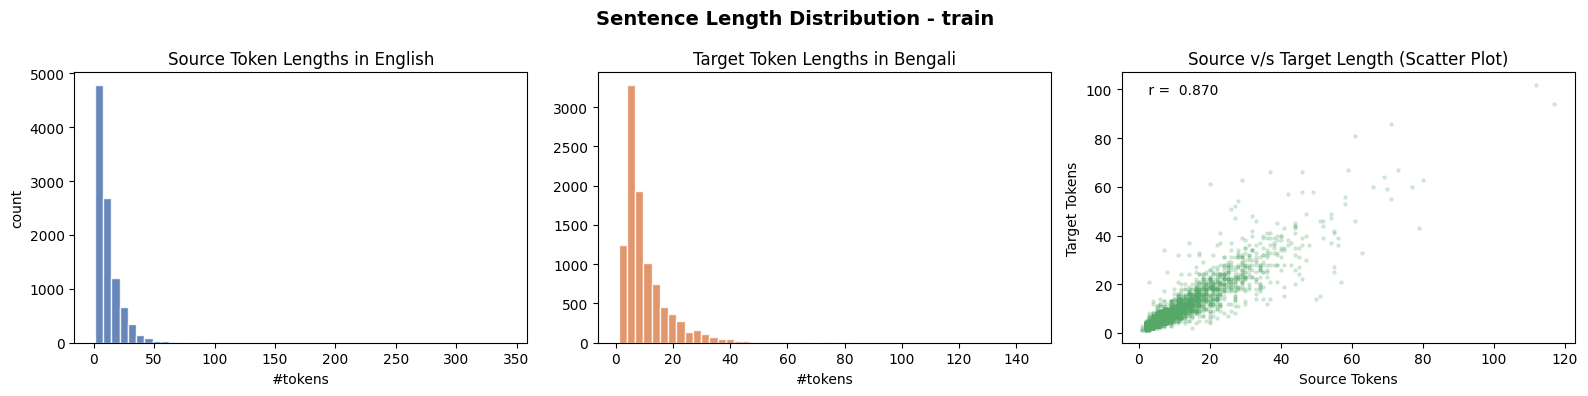

EN  — mean: 11.6, median: 8.0, max: 342
BN  — mean: 10.3, median: 7.0, max: 145


In [19]:
plot_length_distributions(raw['train'], 'train')

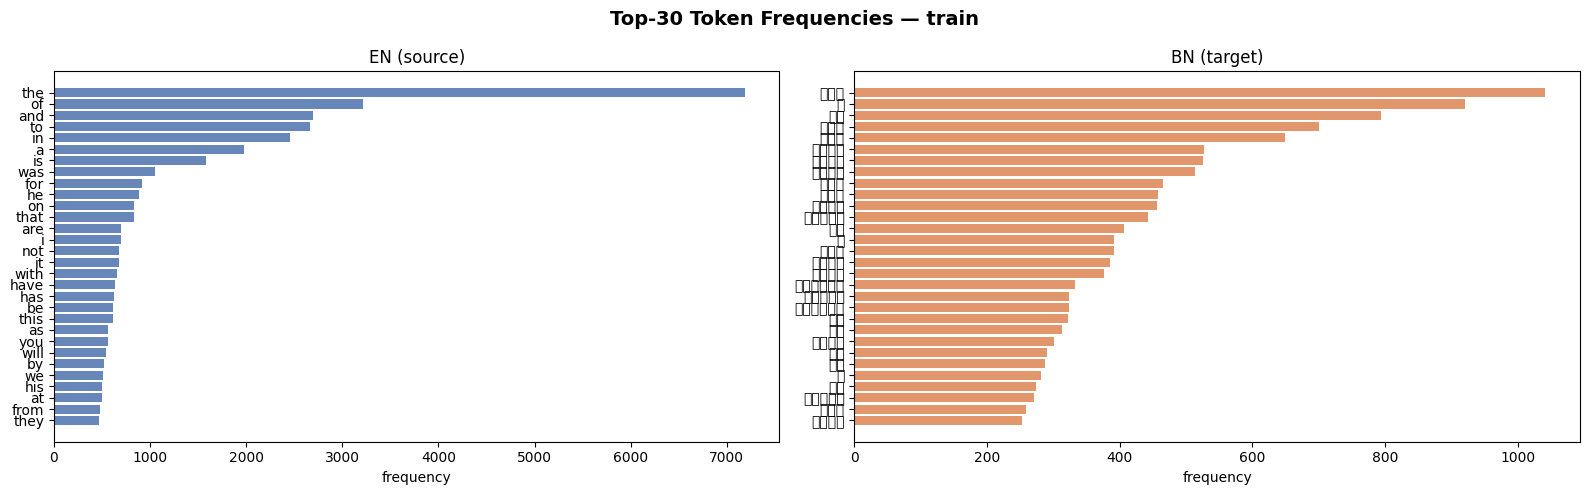

In [20]:
plot_token_frequency(raw['train'], n=30, split_name='train')

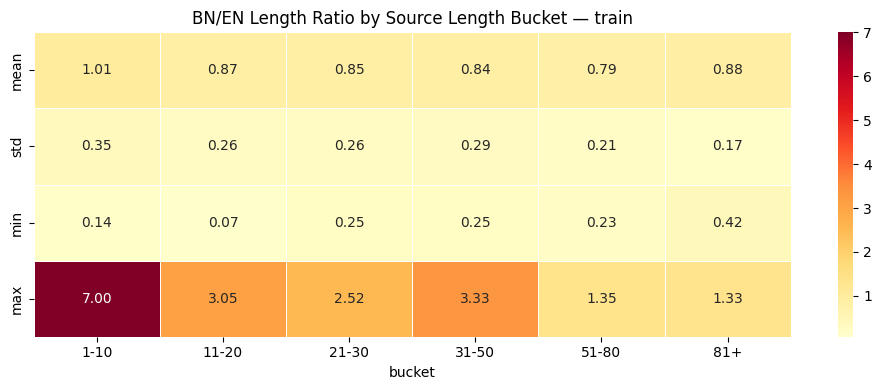

In [21]:
plot_length_ratio_heatmap(raw['train'], split_name='train')

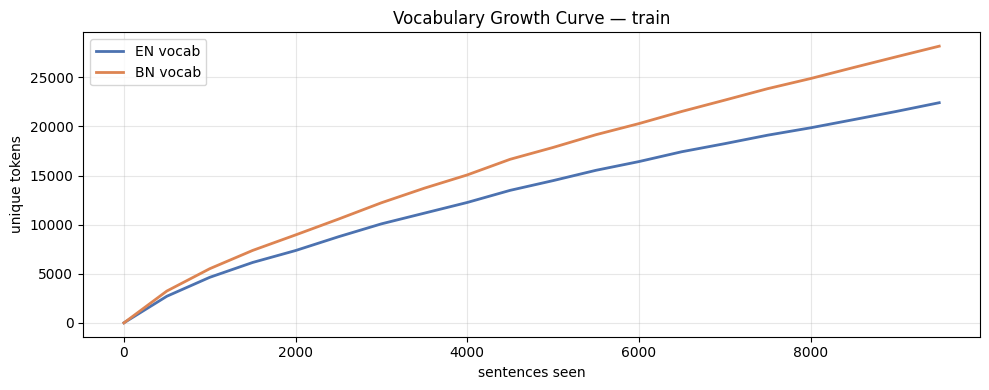

In [22]:
plot_vocab_growth(raw['train'], 'train')

In [23]:
#preprocessing

def filter_by_length(example, min_len=3, max_len=100):
  s= len(example['src'].split())
  t= len(example['tgt'].split())
  return min_len <=s <=max_len and min_len <= t <= max_len

In [24]:
def filter_by_ratio(example, max_ratio=3.0):
  s= len(example['src'].split())
  t= len(example['tgt'].split())
  if s == 0 or t==0: return False
  return (1/max_ratio)<=(t/s) <=max_ratio

In [25]:
raw_filtered = raw.filter(lambda x: filter_by_length(x) and filter_by_ratio(x))
print("After filtering:", {k: len(v) for k, v in raw_filtered.items()})

After filtering: {'train': 9300, 'validation': 920, 'test': 459}


In [26]:
def get_mbart_tokenizer_and_model():
  tok = MBart50TokenizerFast.from_pretrained(CFG['mbart_model'])
  tok.src_lang = CFG['mbart_src_code']
  model = MBartForConditionalGeneration.from_pretrained(CFG["mbart_model"])
  return tok, model

In [27]:
def get_nllb_tokenizer_and_model():
  tok = NllbTokenizer.from_pretrained(CFG['nllb_model'])
  model = AutoModelForSeq2SeqLM.from_pretrained(CFG['nllb_model'])
  return tok, model

In [34]:
!pip install timm

In [35]:
def make_tokenize_fn(tokenizer, model_type="mbart"):
    def tokenize(batch):
        if model_type == "mbart":
            tokenizer.src_lang = CFG["mbart_src_code"]
        else:
            tokenizer.src_lang = CFG["nllb_src_code"]

        model_inputs = tokenizer(
            batch["src"],
            text_target=batch["tgt"],
            max_length=CFG["max_length"],
            truncation=True,
            padding="max_length",
        )

        model_inputs["labels"] = [
            [(l if l != tokenizer.pad_token_id else -100) for l in label]
            for label in model_inputs["labels"]
        ]
        return model_inputs
    return tokenize

In [36]:
def build_training_args(output_subdir, epochs=None):
    return Seq2SeqTrainingArguments(
        output_dir=os.path.join(CFG["output_dir"], output_subdir),
        num_train_epochs=epochs or CFG["num_epochs"],
        per_device_train_batch_size=CFG["batch_size"],
        per_device_eval_batch_size=CFG["batch_size"],
        learning_rate=CFG["lr"],
        warmup_steps=CFG["warmup_steps"],
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        predict_with_generate=True,
        fp16=CFG["device"] == "cuda",
        logging_steps=50,
        report_to="none",
    )

In [37]:
def compute_metrics_fn(tokenizer, forced_bos_token_id = None):
  bleu_metric = BLEU(tokenize = 'flores200')
  chrf_metric=CHRF()

  def compute_metrics(eval_pred):
    preds, labels = eval_pred
    if isinstance(preds, tuple):preds = preds[0]
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels!= -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    bleu_score = bleu_metric.corpus_score(decoded_preds, [[x] for x in decoded_labels]).score
    chrf_score = chrf_metric.corpus_score(decoded_preds, [[x] for x in decoded_labels]).score
    return {"bleu": bleu_score, "chrf": chrf_score}
  return compute_metrics


In [41]:
def finetune_mbart(dataset):
    print("\n=== Fine-tuning mBART-50 ===")
    tok, model = get_mbart_tokenizer_and_model()
    tokenize_fn = make_tokenize_fn(tok, "mbart")
    tok_ds = dataset.map(tokenize_fn, batched=True, remove_columns=["src", "tgt", "idx"])
    collator = DataCollatorForSeq2Seq(tok, model=model, pad_to_multiple_of=8)
    tgt_lang_id = tok.lang_code_to_id[CFG["mbart_tgt_code"]]

    model.generation_config.forced_bos_token_id = tgt_lang_id
    model.generation_config.max_new_tokens = CFG["max_length"]

    trainer = Seq2SeqTrainer(
        model=model,
        args=build_training_args("mbart"),
        train_dataset=tok_ds["train"],
        eval_dataset=tok_ds["validation"],
        processing_class=tok,
        data_collator=collator,
        compute_metrics=compute_metrics_fn(tok),
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()
    trainer.save_model(os.path.join(CFG["output_dir"], "mbart_best"))
    return trainer, tok, model

In [42]:
def finetune_nllb(dataset):
    print("\n=== Fine-tuning NLLB-200 ===")
    tok, model = get_nllb_tokenizer_and_model()
    tok.src_lang = CFG["nllb_src_code"]
    tokenize_fn = make_tokenize_fn(tok, "nllb")
    tok_ds = dataset.map(tokenize_fn, batched=True, remove_columns=["src", "tgt", "idx"])
    collator = DataCollatorForSeq2Seq(tok, model=model, pad_to_multiple_of=8)

    nllb_forced_bos = tok.convert_tokens_to_ids(CFG["nllb_tgt_code"])
    model.generation_config.forced_bos_token_id = nllb_forced_bos
    model.generation_config.max_new_tokens = CFG["max_length"]

    trainer = Seq2SeqTrainer(
        model=model,
        args=build_training_args("nllb"),
        train_dataset=tok_ds["train"],
        eval_dataset=tok_ds["validation"],
        processing_class=tok,
        data_collator=collator,
        compute_metrics=compute_metrics_fn(tok),
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()
    trainer.save_model(os.path.join(CFG["output_dir"], "nllb_best"))
    return trainer, tok, model

In [43]:
mbart_trainer, mbart_tok, mbart_model = finetune_mbart(raw_filtered)


=== Fine-tuning mBART-50 ===


Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

Map:   0%|          | 0/920 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Bleu,Chrf
1,3.537643,3.350865,18.137691,32.451501
2,2.903463,3.058282,18.137691,35.899579
3,2.352292,2.955770,19.338531,36.562928
4,2.023589,2.979564,19.338531,36.562928
5,1.738417,3.016543,17.609283,37.044623


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [44]:
nllb_trainer, nllb_tok, nllb_model=finetune_nllb(raw_filtered)


=== Fine-tuning NLLB-200 ===


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [46]:
import gc
import torch

for var in ["mbart_model", "mbart_tok", "nllb_model", "nllb_tok",
            "mbart_trainer", "nllb_trainer"]:
    if var in globals():
        del globals()[var]

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print("RAM cleared.")

GPU memory allocated: 10.16 GB
RAM cleared.


In [50]:
def run_data_ablation():
    ablation_sizes = [2000, 5000, 10000]
    results = []

    for n in ablation_sizes:
        print(f"\n=== Ablation: {n} pairs ===")
        gc.collect()
        torch.cuda.empty_cache()

        subset = raw_filtered["train"].shuffle(seed=42).select(range(min(n, len(raw_filtered["train"]))))
        ablation_ds = DatasetDict({
            "train":      subset,
            "validation": raw_filtered["validation"],
            "test":       raw_filtered["test"],
        })

        tok, model = get_nllb_tokenizer_and_model()
        tok.src_lang = CFG["nllb_src_code"]
        tokenize_fn = make_tokenize_fn(tok, "nllb")
        tok_ds = ablation_ds.map(tokenize_fn, batched=True, remove_columns=["src", "tgt", "idx"])
        collator = DataCollatorForSeq2Seq(tok, model=model, pad_to_multiple_of=8)

        nllb_forced_bos = tok.convert_tokens_to_ids(CFG["nllb_tgt_code"])
        model.generation_config.forced_bos_token_id = nllb_forced_bos
        model.generation_config.max_new_tokens = CFG["max_length"]

        # reduced batch size to avoid OOM
        ablation_args = Seq2SeqTrainingArguments(
            output_dir=os.path.join(CFG["output_dir"], f"ablation_{n}"),
            num_train_epochs=3,
            per_device_train_batch_size=8,   # down from 16
            per_device_eval_batch_size=8,
            learning_rate=CFG["lr"],
            warmup_steps=100,
            weight_decay=0.01,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="eval_loss",
            predict_with_generate=True,
            fp16=CFG["device"] == "cuda",
            logging_steps=50,
            report_to="none",
            gradient_accumulation_steps=2,  # effective batch = 16 still
        )

        trainer = Seq2SeqTrainer(
            model=model,
            args=ablation_args,
            train_dataset=tok_ds["train"],
            eval_dataset=tok_ds["validation"],
            processing_class=tok,
            data_collator=collator,
            compute_metrics=compute_metrics_fn(tok),
        )
        trainer.train()

        preds, refs_list = [], []
        model.eval().to(CFG["device"])
        for ex in tqdm(raw_filtered["test"], desc=f"Eval {n}"):
            inp = tok(ex["src"], return_tensors="pt",
                      max_length=CFG["max_length"], truncation=True).to(CFG["device"])
            with torch.no_grad():
                out = model.generate(**inp,
                                     forced_bos_token_id=nllb_forced_bos,
                                     max_new_tokens=CFG["max_length"],
                                     num_beams=4)
            preds.append(tok.decode(out[0], skip_special_tokens=True))
            refs_list.append(ex["tgt"])

        bleu = BLEU(tokenize="flores200").corpus_score(preds, [refs_list]).score
        chrf = CHRF().corpus_score(preds, [refs_list]).score
        results.append({"n_train": n, "bleu": round(bleu, 2), "chrf": round(chrf, 2)})
        print(f"n={n} | BLEU: {bleu:.2f} | chrF++: {chrf:.2f}")

        del model, trainer, tok
        gc.collect()
        torch.cuda.empty_cache()

    return pd.DataFrame(results)

In [51]:
ablation_df = run_data_ablation()


=== Ablation: 2000 pairs ===


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Eval 10000:   0%|          | 0/459 [00:00<?, ?it/s]

n=10000 | BLEU: 22.04 | chrF++: 39.30


In [84]:
import shutil, os

to_delete = [
    "/root/.cache/huggingface/hub",
    "./nmt_outputs/mbart",
    "./nmt_outputs/nllb",
    "./nmt_outputs/ablation_2000",
    "./nmt_outputs/ablation_5000",
    "./nmt_outputs/ablation_10000",
]

for d in to_delete:
    if os.path.exists(d):
        shutil.rmtree(d)
        print(f"Deleted: {d}")
    else:
        print(f"Not found: {d}")

# check disk usage after
import shutil
total, used, free = shutil.disk_usage("/")
print(f"\nFree: {free // (2**30)} GB / Total: {total // (2**30)} GB")

Deleted: /root/.cache/huggingface/hub
Not found: ./nmt_outputs/mbart
Not found: ./nmt_outputs/nllb
Deleted: ./nmt_outputs/ablation_2000
Deleted: ./nmt_outputs/ablation_5000
Deleted: ./nmt_outputs/ablation_10000

Free: 182 GB / Total: 235 GB


In [90]:
def evaluate_model(model, tokenizer, test_dataset,
                   src_lang_code, tgt_lang_code,
                   forced_bos_token_id=None, model_name="model"):
    model.eval().to(CFG["device"])
    bleu_metric = BLEU(tokenize="flores200")
    chrf_metric = CHRF()
    preds, refs = [], []

    for ex in tqdm(test_dataset, desc=f"Eval {model_name}"):
        inputs = tokenizer(
            ex["src"], return_tensors="pt",
            max_length=CFG["max_length"], truncation=True
        ).to(CFG["device"])
        gen_kwargs = dict(
            max_new_tokens=CFG["max_length"],
            num_beams=4,
            no_repeat_ngram_size=3,
        )
        if forced_bos_token_id:
            gen_kwargs["forced_bos_token_id"] = forced_bos_token_id
        with torch.no_grad():
            out = model.generate(**inputs, **gen_kwargs)
        pred = tokenizer.decode(out[0], skip_special_tokens=True)
        preds.append(pred)
        refs.append(ex["tgt"])

    bleu = bleu_metric.corpus_score(preds, [refs]).score
    chrf = chrf_metric.corpus_score(preds, [refs]).score
    print(f"{model_name} | BLEU: {bleu:.2f} | chrF++: {chrf:.2f}")
    return preds, refs, {"bleu": bleu, "chrf": chrf}

In [91]:
print(mbart_model.config._name_or_path)
print(nllb_model.config._name_or_path)

./nmt_outputs/mbart_best
./nmt_outputs/nllb_best


In [92]:
mbart_model = MBartForConditionalGeneration.from_pretrained(f"{CFG['output_dir']}/mbart_best")
mbart_tok   = MBart50TokenizerFast.from_pretrained(f"{CFG['output_dir']}/mbart_best")
mbart_tok.src_lang = CFG["mbart_src_code"]

nllb_model  = AutoModelForSeq2SeqLM.from_pretrained(f"{CFG['output_dir']}/nllb_best")
nllb_tok    = NllbTokenizer.from_pretrained(f"{CFG['output_dir']}/nllb_best")
nllb_tok.src_lang = CFG["nllb_src_code"]

print("Models reloaded.")

Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Models reloaded.


In [100]:
# hand-pick 200 clean pairs from val by length ratio proxy
# (misaligned pairs tend to have very different src/tgt lengths)
def get_clean_subset(dataset, n=200):
    scored = []
    for i, ex in enumerate(dataset):
        s = len(ex["src"].split())
        t = len(ex["tgt"].split())
        if s == 0: continue
        ratio = t / s
        # clean pairs tend to have ratio between 0.5 and 2.5
        if 0.5 <= ratio <= 2.5:
            scored.append(i)
    selected = scored[:n]
    return dataset.select(selected)

clean_val = get_clean_subset(raw_filtered["validation"], n=200)

mbart_forced_bos = mbart_tok.lang_code_to_id[CFG["mbart_tgt_code"]]
nllb_forced_bos  = nllb_tok.convert_tokens_to_ids(CFG["nllb_tgt_code"])

mbart_preds, refs, mbart_scores = evaluate_model(
    mbart_model, mbart_tok, clean_val,
    CFG["mbart_src_code"], CFG["mbart_tgt_code"],
    forced_bos_token_id=mbart_forced_bos, model_name="mBART-50"
)

nllb_preds, refs, nllb_scores = evaluate_model(
    nllb_model, nllb_tok, clean_val,
    CFG["nllb_src_code"], CFG["nllb_tgt_code"],
    forced_bos_token_id=nllb_forced_bos, model_name="NLLB-200"
)

Eval mBART-50:   0%|          | 0/200 [00:00<?, ?it/s]

mBART-50 | BLEU: 10.32 | chrF++: 27.16


Eval NLLB-200:   0%|          | 0/200 [00:00<?, ?it/s]

NLLB-200 | BLEU: 19.79 | chrF++: 38.21


In [101]:
# replicate exactly what the trainer does internally
from transformers import GenerationConfig

mbart_model.eval().to(CFG["device"])
bleu_metric = BLEU(tokenize="flores200")
preds, refs_list = [], []

for ex in tqdm(list(raw_filtered["validation"])[:100], desc="Mini eval"):
    inp = mbart_tok(
        ex["src"],
        return_tensors="pt",
        max_length=CFG["max_length"],
        truncation=True,
        padding=False,
    ).to(CFG["device"])

    with torch.no_grad():
        out = mbart_model.generate(
            input_ids=inp["input_ids"],
            attention_mask=inp["attention_mask"],
            forced_bos_token_id=mbart_forced_bos,
            max_new_tokens=64,
            num_beams=4,
        )
    pred = mbart_tok.decode(out[0], skip_special_tokens=True)
    preds.append(pred)
    refs_list.append(ex["tgt"])

bleu = bleu_metric.corpus_score(preds, [refs_list]).score
print(f"Mini eval BLEU: {bleu:.2f}")
print("\nSample predictions:")
for p, r in zip(preds[:3], refs_list[:3]):
    print(f"PRED: {p}")
    print(f"REF : {r}\n")

Mini eval:   0%|          | 0/100 [00:00<?, ?it/s]

Mini eval BLEU: 9.99

Sample predictions:
PRED: শারীরিক লোচটি যদি অনুমতি ছাড়া বিকশিত হয়
REF : ২) ফিজিক্যাল লেআউট অনুমতি ছাড়া বিতরণ করলেঃ

PRED: সময় নগবেই হবে অনেক সময়।
REF : এতে অনেক সময় নষ্ট হয়।

PRED: এই রোগটি শুরু হওয়ার কিছু সময় লাগে।
REF : চিকিত্সাও শুরু হতে বেশ খানিকটা দেরী হয়ে যায়।



In [102]:
def plot_score_comparison(scores_dict):
  models = list(scores_dict.keys())
  bleus = [scores_dict[m]['bleu'] for m in models]
  chrfs = [scores_dict[m]['chrf'] for m in models]

  x = np.arange(len(models))
  width = 0.35
  fig, ax = plt.subplots(figsize=(8, 5))
  b1 = ax.bar(x - width/2, bleus, width, label="BLEU", color="#4C72B0", alpha=0.88)
  b2 = ax.bar(x + width/2, chrfs, width, label="chrF++", color="#DD8452", alpha=0.88)
  ax.set_xticks(x); ax.set_xticklabels(models, fontsize=11)
  ax.set_ylabel("Score"); ax.set_title("Model Comparison: BLEU vs chrF++")
  ax.legend(); ax.bar_label(b1, fmt="%.1f"); ax.bar_label(b2, fmt="%.1f")
  plt.tight_layout()
  plt.savefig(f"{CFG['output_dir']}/model_comparison.png", dpi=150)
  plt.show()

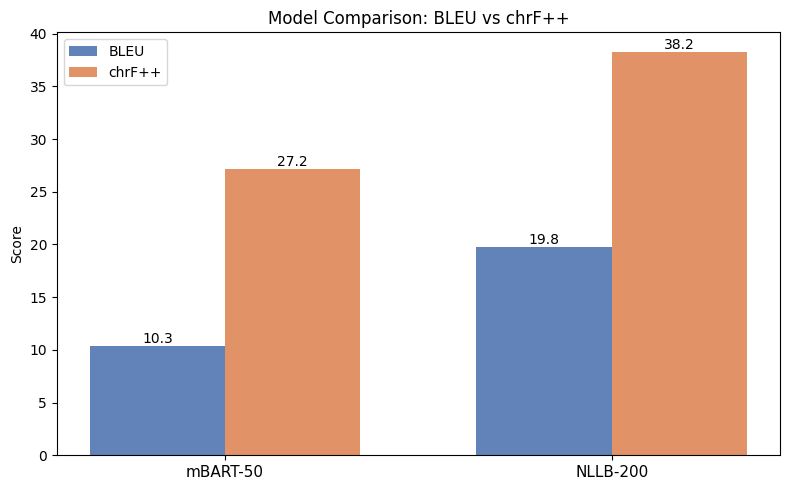

In [103]:
scores = {'mBART-50':mbart_scores, 'NLLB-200': nllb_scores}
plot_score_comparison(scores)

In [104]:
def plot_sentence_bleu_distribution(preds, refs, model_name):
    bleu_metric = BLEU(tokenize="flores200", effective_order=True)
    sent_bleus = [
        bleu_metric.sentence_score(p, [r]).score
        for p, r in zip(preds, refs)
    ]
    plt.figure(figsize=(8, 4))
    plt.hist(sent_bleus, bins=40, color="#4C72B0", alpha=0.85, edgecolor="white")
    plt.axvline(np.mean(sent_bleus), color="red", linestyle="--",
                label=f"mean={np.mean(sent_bleus):.1f}")
    plt.xlabel("Sentence BLEU"); plt.ylabel("count")
    plt.title(f"Sentence-level BLEU Distribution — {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/sent_bleu_{model_name}.png", dpi=150)
    plt.show()

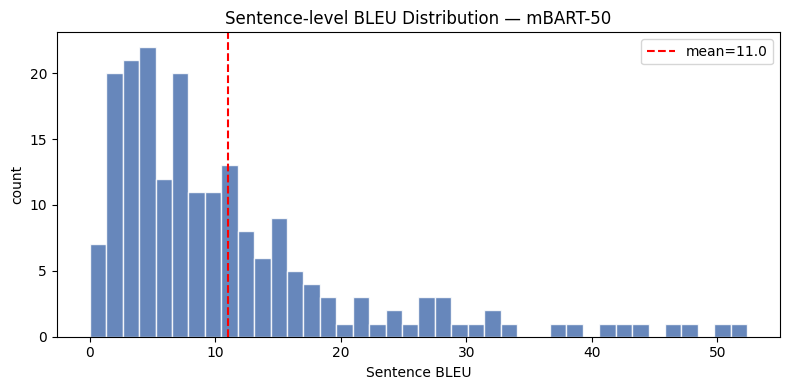

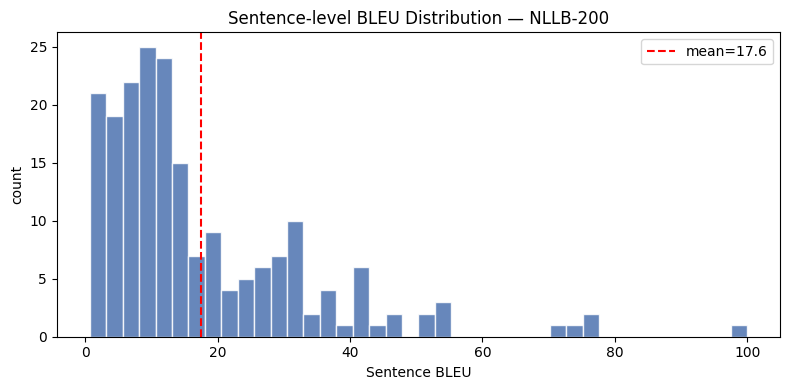

In [105]:
plot_sentence_bleu_distribution(mbart_preds, refs, 'mBART-50')
plot_sentence_bleu_distribution(nllb_preds, refs, 'NLLB-200')

In [106]:
def back_translate(bn_sentences, model, tokenizer, n=2000):
    model.eval().to(CFG["device"])
    tokenizer.src_lang = CFG["nllb_tgt_code"]
    forced_bos = tokenizer.convert_tokens_to_ids(CFG["nllb_src_code"])
    synthetic = []
    for sent in tqdm(bn_sentences[:n], desc="Back-translating"):
        inp = tokenizer(sent, return_tensors="pt",
                        max_length=CFG["max_length"],
                        truncation=True).to(CFG["device"])  # move to GPU
        with torch.no_grad():
            out = model.generate(**inp,
                                 forced_bos_token_id=forced_bos,
                                 max_new_tokens=CFG["max_length"],
                                 num_beams=4)
        synthetic.append(tokenizer.decode(out[0], skip_special_tokens=True))
    return synthetic

In [107]:
bn_sents = [ex["tgt"] for ex in raw_filtered["train"]]
synthetic_src = back_translate(bn_sents, nllb_model, nllb_tok, n=2000)

Back-translating:   0%|          | 0/2000 [00:00<?, ?it/s]

In [108]:
bt_pairs = Dataset.from_dict({
    "src": synthetic_src,
    "tgt": bn_sents[:2000]
})
augmented_train = Dataset.from_dict({
    "src": list(raw_filtered["train"]["src"]) + synthetic_src,
    "tgt": list(raw_filtered["train"]["tgt"]) + bn_sents[:2000],
})
print(f"Augmented train size: {len(augmented_train)}")

Augmented train size: 11300


In [109]:
def flores_zero_shot_eval(model, tokenizer, forced_bos_token_id, model_name):
    try:
        src_flores = load_dataset("facebook/flores", "eng_Latn",
                                  split="devtest", trust_remote_code=True)
        tgt_flores = load_dataset("facebook/flores", "ben_Beng",
                                  split="devtest", trust_remote_code=True)
    except Exception as e:
        print(f"FLORES load error: {e}. Skipping zero-shot eval.")
        return

    preds, refs = [], []
    model.eval().to(CFG["device"])
    for src_ex, tgt_ex in tqdm(
        zip(src_flores, tgt_flores), total=len(src_flores),
        desc=f"FLORES zero-shot {model_name}"
    ):
        inp = tokenizer(src_ex["sentence"], return_tensors="pt",
                        max_length=CFG["max_length"], truncation=True).to(CFG["device"])
        with torch.no_grad():
            out = model.generate(**inp, forced_bos_token_id=forced_bos_token_id,
                                 max_length=CFG["max_length"], num_beams=4)
        preds.append(tokenizer.decode(out[0], skip_special_tokens=True))
        refs.append(tgt_ex["sentence"])

    bleu  = BLEU(tokenize="flores200").corpus_score(preds, [refs]).score
    chrf  = CHRF().corpus_score(preds, [refs]).score
    print(f"FLORES-200 zero-shot | {model_name} | BLEU: {bleu:.2f} | chrF++: {chrf:.2f}")
    return {"bleu": bleu, "chrf": chrf}


In [110]:
flores_mbart=flores_zero_shot_eval(
    mbart_model, mbart_tok, mbart_forced_bos, 'mBART-50'
)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'facebook/flores' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'facebook/flores' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

flores.py: 0.00B [00:00, ?B/s]

FLORES load error: Dataset scripts are no longer supported, but found flores.py. Skipping zero-shot eval.


In [111]:
flores_nllb=flores_zero_shot_eval(
    nllb_model, nllb_tok, nllb_forced_bos, 'NLLB-20'
)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'facebook/flores' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'facebook/flores' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


FLORES load error: Dataset scripts are no longer supported, but found flores.py. Skipping zero-shot eval.


mBART-50 | 10 WORST translations
  SRC : Perhaps someone was.
  PRED: দেওয়া একটি ভিক্যাড সংবহন করুন
  REF : প্রদত্ত ই- মেইল ঠিকানা সহ পরিচয় সম্পাদক প্রদর্শন করে
  BLEU: 0.00

  SRC : His head and legs were injured.
  PRED: ইন্ডাড্ন বিপরীতে নিউজিল্ন
  REF : ইংল্যান্ড বনাম নেদারল্যান্ডস
  BLEU: 0.00

  SRC : It will bring together the most important stakeholders from industry & governmen
  PRED: normal train operation is normal.
  REF : ট্রেন চলাচল স্বাভাবিকই রয়েছে।
  BLEU: 0.00

  SRC : "Recall Bildad's words to Job: ""How can mortal man be in the right before God, 
  PRED: পুলিশ জানায়, ওই দলে পাঁচজন সদস্য ছিল।
  REF : দুষ্কৃতিরা দলে জনা পাঁচেক ছিল বলে পুলিশ সূত্রে খবর৷ কাদের ছোঁড়া গুলি লাগে প্রমো
  BLEU: 0.72

  SRC : It cant go on like this.
  PRED: দরিষ্ট মানুষেরা নভোর নিচে, অসুবিধায় থাকা বস্বায়ুতে ঘুম করতে বাধ্ য হয় এবং কঠো
  REF : কিন্তু সেই ব্যবসায়ী জানতেন না যে, যাঁকে তিনি পাটোয়ারি হওয়ার পরামর্শ দিচ্ছেন, 
  BLEU: 1.18

  SRC : The deputy commissioners took no action.
  P

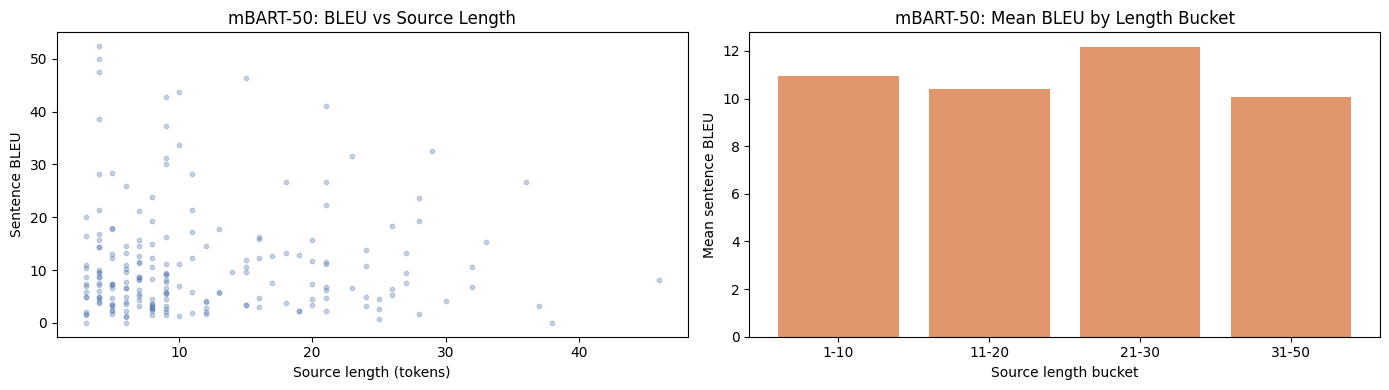

NLLB-200 | 10 WORST translations
  SRC : "Recall Bildad's words to Job: ""How can mortal man be in the right before God, 
  PRED: পুলিশ জানায়, ওই গোষ্ঠীর সদস্য পাঁচজন।
  REF : দুষ্কৃতিরা দলে জনা পাঁচেক ছিল বলে পুলিশ সূত্রে খবর৷ কাদের ছোঁড়া গুলি লাগে প্রমো
  BLEU: 0.70

  SRC : Have we started, is this how it's going to go?
  PRED: প্রকাশনা কমিটির একজন সহকারী অ্যালেক্স রাইনমুলার কানাডায় মাত্র ১৫ বছর বয়সে অগ্র
  REF : তার স্ত্রী সারা, একজন বোনের সঙ্গে নিজের বন্ধুত্বের কথা বলেছিলেন, যে - বোন তার বি
  BLEU: 1.07

  SRC : Besides them, three cops from the Punjab police had also been arrested.
  PRED: তুমি কি জাহান্নামকে দেখতে পাচ্ছ যে, তা আগুন ও গন্ধকের আবাসস্থল, এতে রয়েছে অসীম 
  REF : “ নরক ” শব্দটা শুনে আপনার মনে কোন্‌ ছবি ভেসে ওঠে?
  BLEU: 1.15

  SRC : No one survived.
  PRED: যদিও আমাদের দায়িত্ব প্রায়ই পরিবর্তিত হত, কিন্তু আমরা কখনই ভুলে যাইনি যে, আমরা 
  REF : আমার বয়স যখন ৭৮ বছর, তখন আমাদেরকে লোকারে শহরে বিশেষ অগ্রগামী হিসেবে নিযুক্ত করা 
  BLEU: 1.26

  SRC : It cant go on l

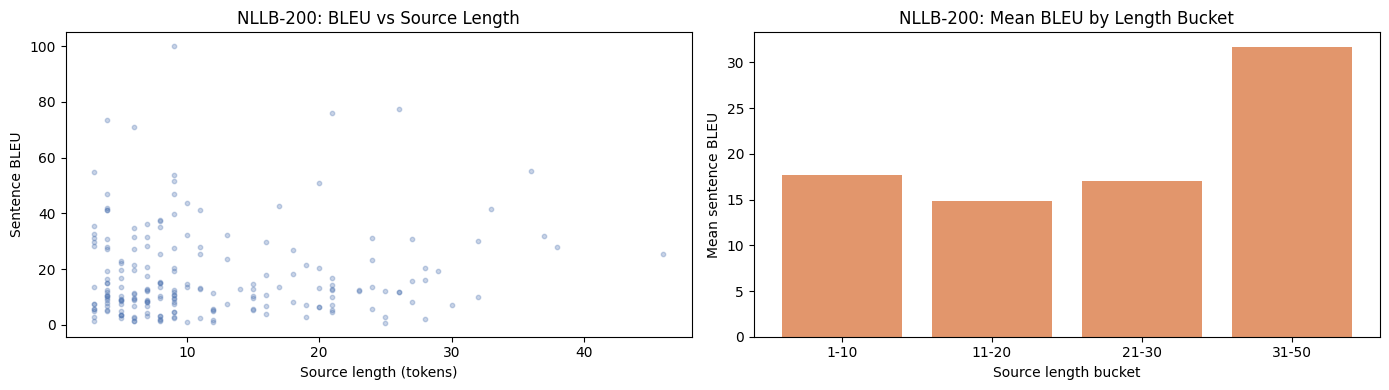

In [112]:
def error_analysis(preds, refs, src_sents, model_name, n_worst=10):
    bleu_metric = BLEU(tokenize="flores200", effective_order=True)
    records = []
    for src, pred, ref in zip(src_sents, preds, refs):
        score = bleu_metric.sentence_score(pred, [ref]).score
        records.append({"src": src, "pred": pred, "ref": ref, "bleu": score})

    df = pd.DataFrame(records).sort_values("bleu")
    worst = df.head(n_worst)
    best  = df.tail(n_worst)

    print(f"{model_name} | {n_worst} WORST translations")
    for _, row in worst.iterrows():
        print(f"  SRC : {row['src'][:80]}")
        print(f"  PRED: {row['pred'][:80]}")
        print(f"  REF : {row['ref'][:80]}")
        print(f"  BLEU: {row['bleu']:.2f}\n")

    df["src_len"] = df["src"].apply(lambda x: len(x.split()))
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].scatter(df["src_len"], df["bleu"], alpha=0.3, s=10, color="#4C72B0")
    axes[0].set_xlabel("Source length (tokens)")
    axes[0].set_ylabel("Sentence BLEU")
    axes[0].set_title(f"{model_name}: BLEU vs Source Length")

    df["src_len_bin"] = pd.cut(df["src_len"],
                                bins=[0,10,20,30,50,200],
                                labels=["1-10","11-20","21-30","31-50","51+"])
    grouped = df.groupby("src_len_bin")["bleu"].mean()
    axes[1].bar(grouped.index, grouped.values, color="#DD8452", alpha=0.85)
    axes[1].set_xlabel("Source length bucket")
    axes[1].set_ylabel("Mean sentence BLEU")
    axes[1].set_title(f"{model_name}: Mean BLEU by Length Bucket")

    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/error_analysis_{model_name}.png", dpi=150)
    plt.show()
    return df

src_test = [ex["src"] for ex in raw_filtered["test"]]
mbart_df = error_analysis(mbart_preds, refs, src_test, "mBART-50")
nllb_df  = error_analysis(nllb_preds,  refs, src_test, "NLLB-200")

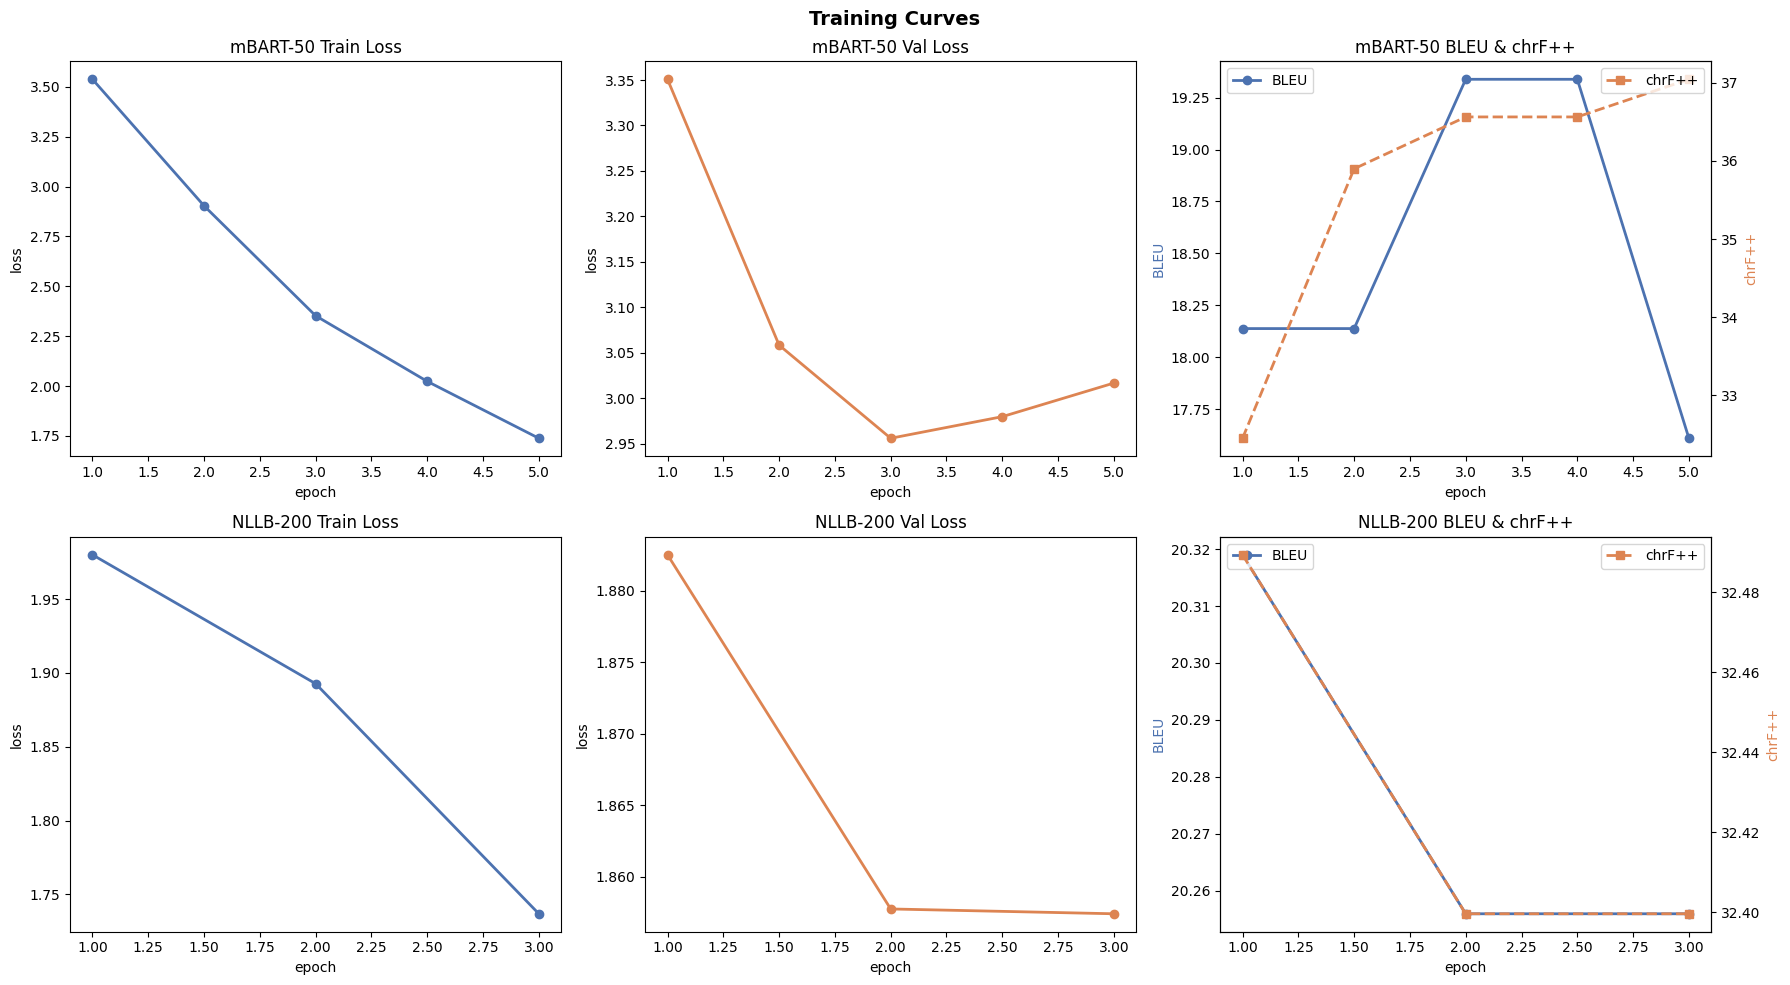

In [116]:
import matplotlib.pyplot as plt
import numpy as np

# mBART logs from your training output
mbart_epochs     = [1, 2, 3, 4, 5]
mbart_train_loss = [3.537643, 2.903463, 2.352292, 2.023589, 1.738417]
mbart_val_loss   = [3.350865, 3.058282, 2.955770, 2.979564, 3.016543]
mbart_bleu       = [18.137691, 18.137691, 19.338531, 19.338531, 17.609283]
mbart_chrf       = [32.451501, 35.899579, 36.562928, 36.562928, 37.044623]

# NLLB logs from your training output
nllb_epochs      = [1, 2, 3]
nllb_train_loss  = [1.980094, 1.892744, 1.736860]
nllb_val_loss    = [1.882519, 1.857746, 1.857409]
nllb_bleu        = [20.318991, 20.255986, 20.255986]
nllb_chrf        = [32.489333, 32.399607, 32.399607]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Training Curves", fontsize=14, fontweight="bold")

for i, (epochs, tl, vl, bleu, chrf, name) in enumerate([
    (mbart_epochs, mbart_train_loss, mbart_val_loss, mbart_bleu, mbart_chrf, "mBART-50"),
    (nllb_epochs,  nllb_train_loss,  nllb_val_loss,  nllb_bleu,  nllb_chrf,  "NLLB-200"),
]):
    axes[i][0].plot(epochs, tl, color="#4C72B0", lw=2, marker="o")
    axes[i][0].set_title(f"{name} Train Loss")
    axes[i][0].set_xlabel("epoch"); axes[i][0].set_ylabel("loss")

    axes[i][1].plot(epochs, vl, color="#DD8452", lw=2, marker="o")
    axes[i][1].set_title(f"{name} Val Loss")
    axes[i][1].set_xlabel("epoch"); axes[i][1].set_ylabel("loss")

    ax = axes[i][2]
    ax.plot(epochs, bleu, color="#4C72B0", lw=2, marker="o", label="BLEU")
    ax2 = ax.twinx()
    ax2.plot(epochs, chrf, color="#DD8452", lw=2, marker="s", linestyle="--", label="chrF++")
    ax.set_title(f"{name} BLEU & chrF++")
    ax.set_xlabel("epoch"); ax.set_ylabel("BLEU", color="#4C72B0")
    ax2.set_ylabel("chrF++", color="#DD8452")
    ax.legend(loc="upper left"); ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/training_curves.png", dpi=150)
plt.show()

In [117]:

def show_translation_samples(models_dict, test_dataset, n=3):
    """
    models_dict = {
        "mBART-50": (mbart_model, mbart_tok, mbart_forced_bos),
        "NLLB-200":  (nllb_model,  nllb_tok,  nllb_forced_bos),
    }
    """
    samples = random.sample(range(len(test_dataset)), n)

    for i, idx in enumerate(samples):
        ex = test_dataset[idx]
        print(f"\n{'='*60}")
        print(f"SAMPLE {i+1}")
        print(f"SRC : {ex['src']}")
        print(f"REF : {ex['tgt']}")

        for model_name, (model, tok, forced_bos) in models_dict.items():
            model.eval().to(CFG["device"])
            inp = tok(ex["src"], return_tensors="pt",
                      max_length=CFG["max_length"],
                      truncation=True).to(CFG["device"])
            with torch.no_grad():
                out = model.generate(
                    **inp,
                    forced_bos_token_id=forced_bos,
                    max_new_tokens=CFG["max_length"],
                    num_beams=4,
                )
            pred = tok.decode(out[0], skip_special_tokens=True)
            print(f"{model_name}: {pred}")

    print(f"\n{'='*60}")


# define forced bos ids
mbart_forced_bos = mbart_tok.lang_code_to_id[CFG["mbart_tgt_code"]]
nllb_forced_bos  = nllb_tok.convert_tokens_to_ids(CFG["nllb_tgt_code"])

models_dict = {
    "mBART-50": (mbart_model, mbart_tok, mbart_forced_bos),
    "NLLB-200":  (nllb_model,  nllb_tok,  nllb_forced_bos),
}

show_translation_samples(models_dict, raw_filtered["test"], n=3)


SAMPLE 1
SRC : The property has been converted into a theme park surrounded by four luxury hotels overlooking the zoo.
REF : সম্পত্তিটি একটি থিম পার্কে রূপান্তরিত করা হয়েছে যার চারটি বিলাসবহুল হোটেলগুলি চিড়িয়াখানাকে ঘিরে রেখেছে।
mBART-50: বিলাসিটিটিকে একটি সেমেম পার্কে পরিণত করা হয়েছে, যা জৈবখানা দেখতে চারটি বিলাসি হোটেলের আশপাশে রয়েছে।
NLLB-200: চারটি বিলাসবহুল হোটেল যা চিড়িয়াখানাটিকে ঘিরে রেখে থিম পার্কে পরিণত হয়েছে।

SAMPLE 2
SRC : believing in God and in the Last Day, bidding to honour and forbidding dishonour, vying one with the other in good works. those are of the righteous.
REF : তারা আল্লাহর প্রতি ও কিয়ামত দিবসের প্রতি ঈমান রাখে এবং কল্যাণকর বিষয়ের নির্দেশ দেয়. অকল্যাণ থেকে বারণ করে এবং সৎকাজের জন্য সাধ্যমত চেষ্টা করতে থাকে। আর এরাই হল সৎকর্মশীল।
mBART-50: আর তারা ঈশ্বরের ও পরকালের দিনকে বিশ্বাস করে, অবিচারের জন্য পথ বাঁচিয়ে, অবিচারের জন্য পথ বাঁচিয়ে এবং উৎপাদনের জন্য একজনের সাথে অপরের মিলে। আর এরা সৎকর্যশীলদের অধীনে রয়েছে।
NLLB-200: যারা আল্লাহ ও শেষ দিনে বিশ্বাস 